In [2]:
games = [
    "Red Light Green Light",
    "Honeycomb",
    "Tug of War",
    "Marbles",
    "Glass Bridge",
    "Final Squid Game"
]

In [22]:
import pandas as pd
import random

# Step 1: define games
games = [
    "Red Light Green Light",
    "Tug of War",
    "Glass Bridge",
    "Marbles",
    "Honeycomb",
    "Final Squid Game"
]

data = []

# Step 2: loop
for i in range(15000):   
    game = random.choice(games)
    
    age = random.randint(20, 45)
    gender = random.choice(["Male", "Female"])
    
    if game == "Glass Bridge":
        status = random.choices(["Alive", "Dead"], weights=[2,8])[0]
    elif game == "Tug of War":
        status = random.choices(["Alive", "Dead"], weights=[4,6])[0]
    else:
        status = random.choice(["Alive", "Dead"])
    
    money = random.randint(0, 1000) if status == "Alive" else 0
    
    data.append({
        "player_id": i+1,
        "age": age,
        "gender": gender,
        "game": game,
        "status": status,
        "money_won": money,
        "round": random.randint(1,6)
    })

# Step 3: create dataframe
df = pd.DataFrame(data)

# Step 4: print
print(df.head())
   

   player_id  age  gender          game status  money_won  round
0          1   36    Male     Honeycomb  Alive        496      1
1          2   28  Female     Honeycomb   Dead          0      1
2          3   24  Female  Glass Bridge  Alive        751      6
3          4   22  Female  Glass Bridge   Dead          0      3
4          5   44  Female       Marbles   Dead          0      1


In [23]:
df[df["status"] == "Dead"]["game"].value_counts()

game
Glass Bridge             2039
Tug of War               1420
Final Squid Game         1287
Red Light Green Light    1242
Honeycomb                1225
Marbles                  1183
Name: count, dtype: int64

In [24]:
df.groupby("gender")["status"].value_counts()

gender  status
Female  Dead      4299
        Alive     3311
Male    Dead      4097
        Alive     3293
Name: count, dtype: int64

In [25]:
df.groupby("game")["money_won"].mean()

game
Final Squid Game         246.070570
Glass Bridge              96.162141
Honeycomb                257.206704
Marbles                  248.128226
Red Light Green Light    249.658838
Tug of War               215.585772
Name: money_won, dtype: float64

In [26]:
df.groupby("game")["status"].value_counts(normalize=True).mul(100).round(2)

game                   status
Final Squid Game       Alive     50.10
                       Dead      49.90
Glass Bridge           Dead      80.24
                       Alive     19.76
Honeycomb              Alive     51.12
                       Dead      48.88
Marbles                Alive     50.75
                       Dead      49.25
Red Light Green Light  Alive     50.56
                       Dead      49.44
Tug of War             Dead      57.72
                       Alive     42.28
Name: proportion, dtype: float64

In [27]:
df.groupby("status")["age"].mean()

status
Alive    32.639764
Dead     32.461768
Name: age, dtype: float64

In [32]:
import matplotlib.pyplot as plt

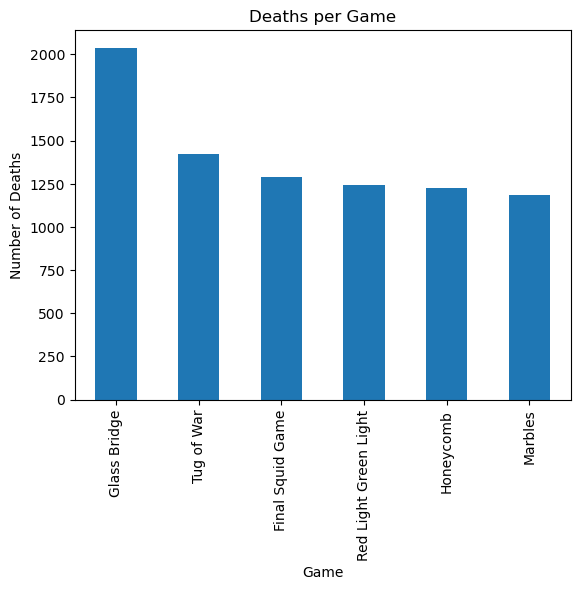

In [33]:
df[df["status"] == "Dead"]["game"].value_counts().plot(kind="bar")
plt.title("Deaths per Game")
plt.xlabel("Game")
plt.ylabel("Number of Deaths")
plt.show()

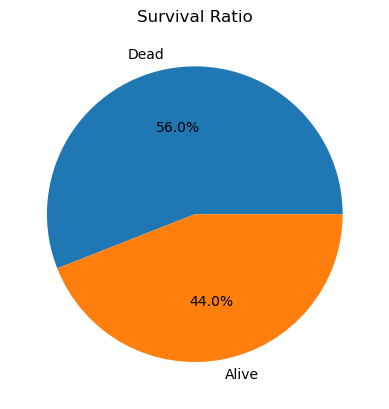

In [34]:
df["status"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Survival Ratio")
plt.ylabel("")
plt.show()


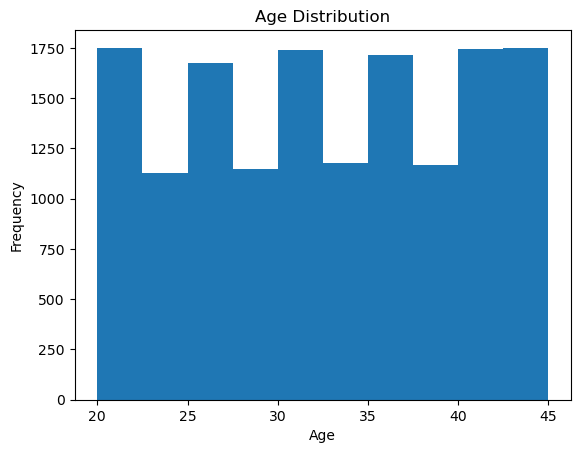

In [35]:
df["age"].plot(kind="hist", bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

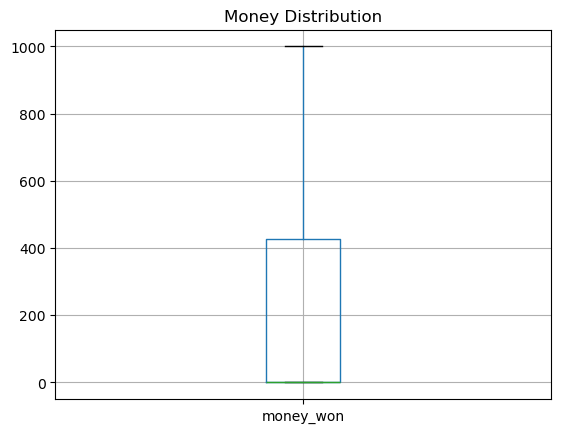

In [36]:
df.boxplot(column="money_won")
plt.title("Money Distribution")
plt.show()

In [31]:
death_rate = df.groupby("game")["status"].value_counts(normalize=True).unstack()
print(death_rate)

status                    Alive      Dead
game                                     
Final Squid Game       0.500969  0.499031
Glass Bridge           0.197560  0.802440
Honeycomb              0.511173  0.488827
Marbles                0.507494  0.492506
Red Light Green Light  0.505573  0.494427
Tug of War             0.422764  0.577236


# 🎮 Squid Game Data Analysis


This project analyzes player survival, game difficulty, and money distribution in a Squid Game dataset using Python.

In [38]:
import pandas as pd

data = {
    "player_id": [1,2,3,4,5,6],
    "game": ["Red Light", "Glass Bridge", "Tug of War", "Marbles", "Glass Bridge", "Red Light"],
    "status": ["Alive", "Dead", "Alive", "Dead", "Dead", "Alive"],
    "money_won": [100, 0, 200, 0, 0, 150]
}

df = pd.DataFrame(data)

df

,player_id,game,status,money_won
0,1,Red Light,Alive,100
1,2,Glass Bridge,Dead,0
2,3,Tug of War,Alive,200
3,4,Marbles,Dead,0
4,5,Glass Bridge,Dead,0
5,6,Red Light,Alive,150


## 🔍 Data Analysis


In [39]:
# Count Alive vs Dead
df["status"].value_counts()

status
Alive    3
Dead     3
Name: count, dtype: int64

## 📊 Visualizations

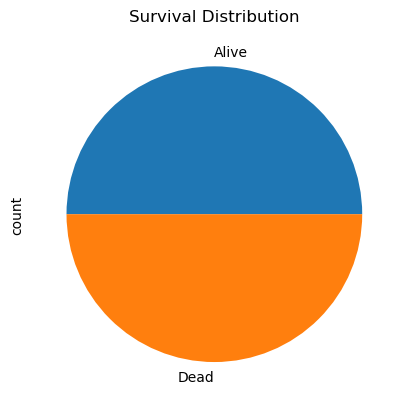

In [40]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="pie")
plt.title("Survival Distribution")
plt.show()

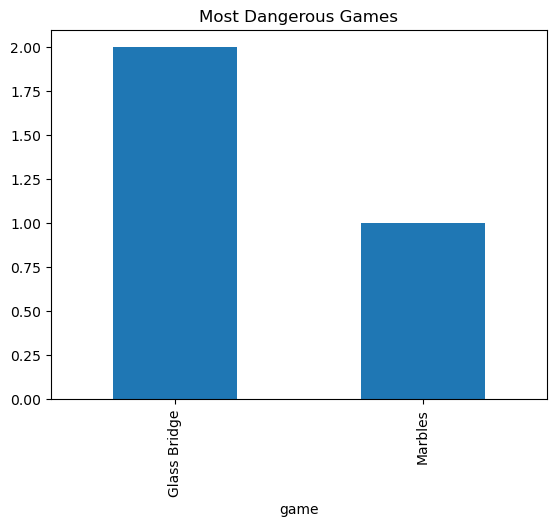

In [41]:
df[df["status"] == "Dead"]["game"].value_counts().plot(kind="bar")
plt.title("Most Dangerous Games")
plt.show()